----

In [1]:
# Importar las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import MaxNLocator

# Configurar el estilo de los gráficos
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [2]:

# Cargar los datasets
companies_df = pd.read_csv('/datasets/project_sql_result_01.csv')
dropoff_df = pd.read_csv('/datasets/project_sql_result_04.csv')

print("=== DATASET DE EMPRESAS DE TAXIS ===")
print(f"Forma del dataset: {companies_df.shape}")
print(f"Columnas: {list(companies_df.columns)}")
print("\nPrimeras 5 filas:")
print(companies_df.head())
print("\nInformación del dataset:")
print(companies_df.info())

print("\n" + "="*50)
print("=== DATASET DE UBICACIONES DE FINALIZACIÓN ===")
print(f"Forma del dataset: {dropoff_df.shape}")
print(f"Columnas: {list(dropoff_df.columns)}")
print("\nPrimeras 5 filas:")
print(dropoff_df.head())
print("\nInformación del dataset:")
print(dropoff_df.info())

=== DATASET DE EMPRESAS DE TAXIS ===
Forma del dataset: (64, 2)
Columnas: ['company_name', 'trips_amount']

Primeras 5 filas:
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None

=== DATASET DE UBICACIONES DE FINALIZACIÓN ===
Forma del dataset: (94, 2)
Columnas: ['dropoff_location_name', 'average_trips']

Primeras 5 filas:
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1   

In [3]:
# Verificar y limpiar los datos
print("=== VERIFICACIÓN DE TIPOS DE DATOS Y LIMPIEZA ===")

# Dataset de empresas
print("Dataset de empresas:")
print(f"Valores nulos en company_name: {companies_df['company_name'].isnull().sum()}")
print(f"Valores nulos en trips_amount: {companies_df['trips_amount'].isnull().sum()}")
print(f"Tipo de datos trips_amount: {companies_df['trips_amount'].dtype}")

# Dataset de ubicaciones
print("\nDataset de ubicaciones:")
print(f"Valores nulos en dropoff_location_name: {dropoff_df['dropoff_location_name'].isnull().sum()}")
print(f"Valores nulos en average_trips: {dropoff_df['average_trips'].isnull().sum()}")
print(f"Tipo de datos average_trips: {dropoff_df['average_trips'].dtype}")

# Verificar estadísticas básicas
print("\n=== ESTADÍSTICAS BÁSICAS ===")
print("\nEmpresas de taxis - Estadísticas de viajes:")
print(companies_df['trips_amount'].describe())

print("\nUbicaciones - Estadísticas de promedio de viajes:")
print(dropoff_df['average_trips'].describe())

=== VERIFICACIÓN DE TIPOS DE DATOS Y LIMPIEZA ===
Dataset de empresas:
Valores nulos en company_name: 0
Valores nulos en trips_amount: 0
Tipo de datos trips_amount: int64

Dataset de ubicaciones:
Valores nulos en dropoff_location_name: 0
Valores nulos en average_trips: 0
Tipo de datos average_trips: float64

=== ESTADÍSTICAS BÁSICAS ===

Empresas de taxis - Estadísticas de viajes:
count       64.000000
mean      2145.484375
std       3812.310186
min          2.000000
25%         20.750000
50%        178.500000
75%       2106.500000
max      19558.000000
Name: trips_amount, dtype: float64

Ubicaciones - Estadísticas de promedio de viajes:
count       94.000000
mean       599.953728
std       1714.591098
min          1.800000
25%         14.266667
50%         52.016667
75%        298.858333
max      10727.466667
Name: average_trips, dtype: float64


In [4]:
# Identificar los top 10 barrios por finalizaciones de viajes
top_10_neighborhoods = dropoff_df.nlargest(10, 'average_trips')

print("=== TOP 10 BARRIOS POR FINALIZACIÓN DE VIAJES ===")
print(top_10_neighborhoods.to_string(index=False))

# También veamos las top 15 empresas para una mejor visualización
top_15_companies = companies_df.nlargest(15, 'trips_amount')

print("\n=== TOP 15 EMPRESAS DE TAXIS POR NÚMERO DE VIAJES ===")
print(top_15_companies.to_string(index=False))

=== TOP 10 BARRIOS POR FINALIZACIÓN DE VIAJES ===
dropoff_location_name  average_trips
                 Loop   10727.466667
          River North    9523.666667
        Streeterville    6664.666667
            West Loop    5163.666667
               O'Hare    2546.900000
            Lake View    2420.966667
           Grant Park    2068.533333
        Museum Campus    1510.000000
           Gold Coast    1364.233333
   Sheffield & DePaul    1259.766667

=== TOP 15 EMPRESAS DE TAXIS POR NÚMERO DE VIAJES ===
                           company_name  trips_amount
                              Flash Cab         19558
              Taxi Affiliation Services         11422
                      Medallion Leasing         10367
                             Yellow Cab          9888
        Taxi Affiliation Service Yellow          9299
              Chicago Carriage Cab Corp          9181
                           City Service          8448
                               Sun Taxi          7701
  

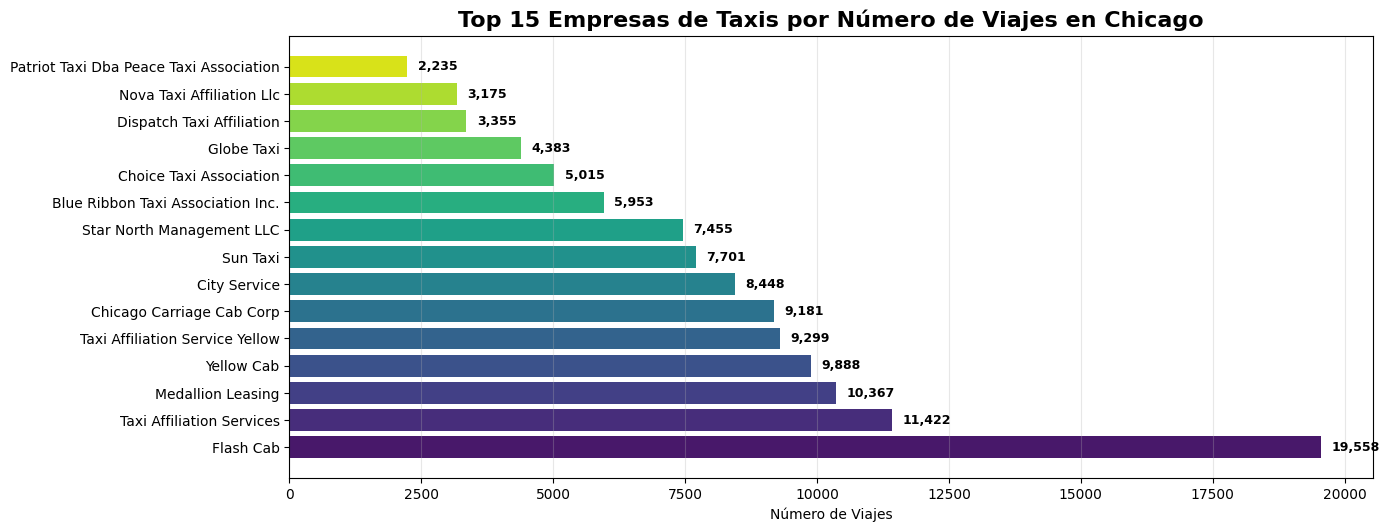


=== ANÁLISIS DE CONCENTRACIÓN DEL MERCADO ===
Total de viajes de todas las empresas: 137,311
Viajes de las top 5 empresas: 60,534
Concentración del mercado (top 5): 44.1%


In [5]:
# GRÁFICO 1: Top 15 Empresas de Taxis por Número de Viajes
plt.figure(figsize=(14, 10))
plt.subplot(2, 1, 1)

colors = sns.color_palette("viridis", len(top_15_companies))
bars = plt.barh(range(len(top_15_companies)), top_15_companies['trips_amount'], color=colors)

plt.yticks(range(len(top_15_companies)), top_15_companies['company_name'])
plt.xlabel('Número de Viajes')
plt.title('Top 15 Empresas de Taxis por Número de Viajes en Chicago', fontsize=16, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, (bar, value) in enumerate(zip(bars, top_15_companies['trips_amount'])):
    plt.text(value + 200, i, f'{value:,}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Calcular algunos estadísticos para las empresas
total_trips_companies = companies_df['trips_amount'].sum()
top_5_companies_share = top_15_companies.head(5)['trips_amount'].sum()
market_concentration = (top_5_companies_share / total_trips_companies) * 100

print(f"\n=== ANÁLISIS DE CONCENTRACIÓN DEL MERCADO ===")
print(f"Total de viajes de todas las empresas: {total_trips_companies:,}")
print(f"Viajes de las top 5 empresas: {top_5_companies_share:,}")
print(f"Concentración del mercado (top 5): {market_concentration:.1f}%")

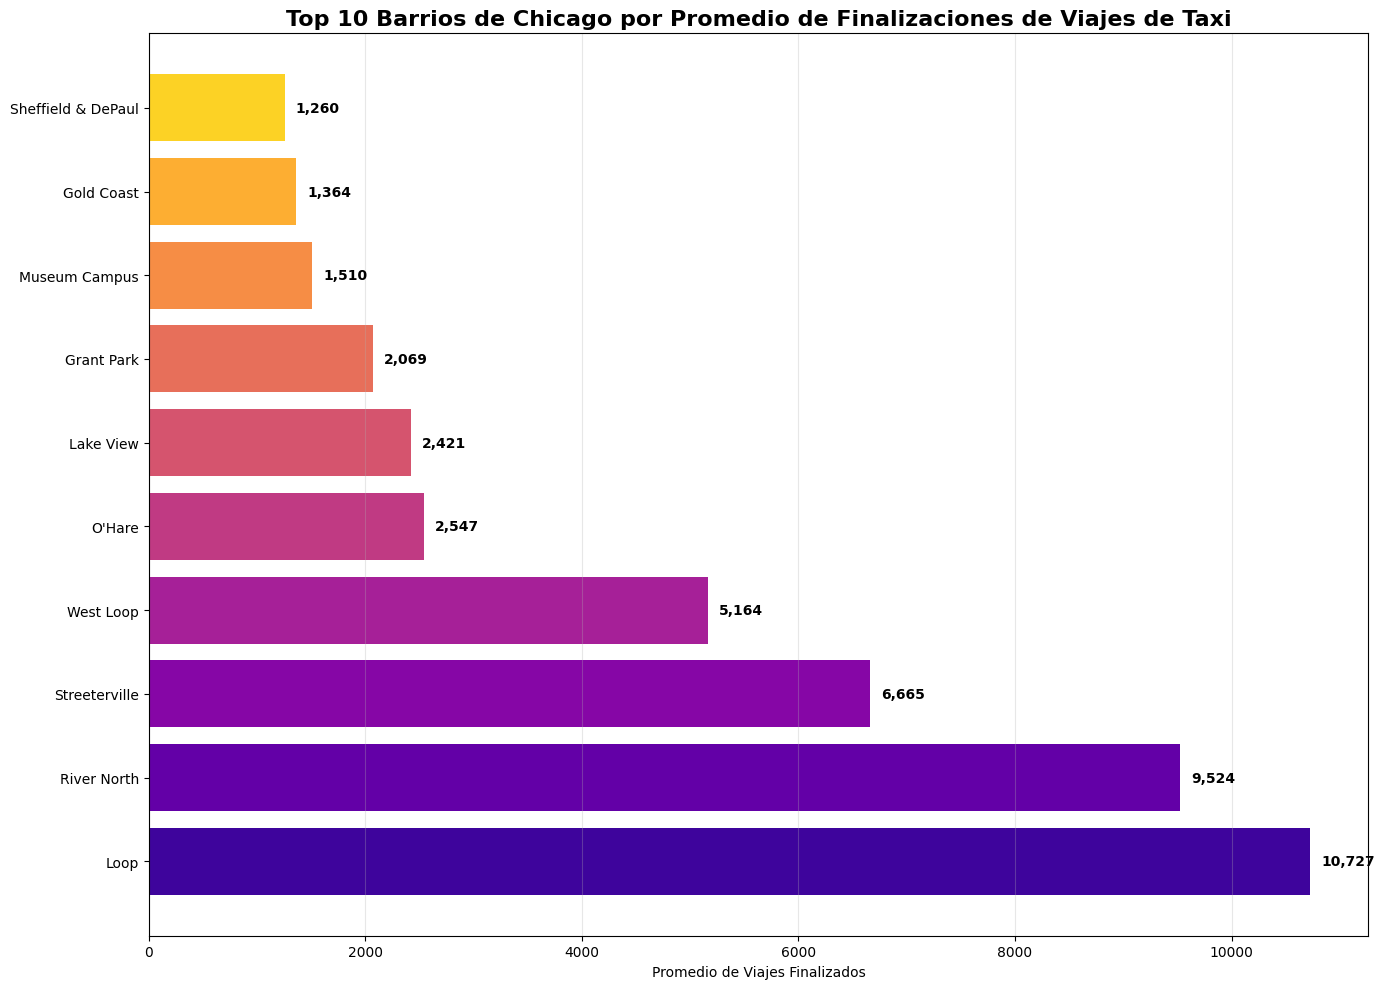


=== ANÁLISIS DE CONCENTRACIÓN POR BARRIOS ===
Total promedio de viajes de todos los barrios: 56,396
Promedio de viajes de los top 3 barrios: 26,916
Concentración en los top 3 barrios: 47.7%


In [6]:
# GRÁFICO 2: Top 10 Barrios por Promedio de Finalizaciones de Viajes
plt.figure(figsize=(14, 10))

# Crear el gráfico de barras horizontales
colors = sns.color_palette("plasma", len(top_10_neighborhoods))
bars = plt.barh(range(len(top_10_neighborhoods)), top_10_neighborhoods['average_trips'], color=colors)

# Configurar etiquetas y título
plt.yticks(range(len(top_10_neighborhoods)), top_10_neighborhoods['dropoff_location_name'])
plt.xlabel('Promedio de Viajes Finalizados')
plt.title('Top 10 Barrios de Chicago por Promedio de Finalizaciones de Viajes de Taxi', fontsize=16, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, (bar, value) in enumerate(zip(bars, top_10_neighborhoods['average_trips'])):
    plt.text(value + 100, i, f'{value:,.0f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Análisis de los barrios
total_avg_trips = dropoff_df['average_trips'].sum()
top_3_neighborhoods_trips = top_10_neighborhoods.head(3)['average_trips'].sum()
neighborhood_concentration = (top_3_neighborhoods_trips / total_avg_trips) * 100

print(f"\n=== ANÁLISIS DE CONCENTRACIÓN POR BARRIOS ===")
print(f"Total promedio de viajes de todos los barrios: {total_avg_trips:,.0f}")
print(f"Promedio de viajes de los top 3 barrios: {top_3_neighborhoods_trips:,.0f}")
print(f"Concentración en los top 3 barrios: {neighborhood_concentration:.1f}%")

# Conclusiones y Análisis de Resultados

## Análisis del Gráfico de Empresas de Taxis

### Principales Hallazgos:

1. **Dominancia de Flash Cab**: Con 19,558 viajes, Flash Cab es claramente la empresa líder, representando aproximadamente el 14.2% del mercado total.

2. **Concentración del Mercado**: Las top 5 empresas (Flash Cab, Taxi Affiliation Services, Medallion Leasin, Yellow Cab, y Taxi Affiliation Service Yellow) concentran el **44.1%** del mercado, indicando una estructura oligopolística.

3. **Distribución Desigual**: Existe una gran disparidad entre las empresas principales y las más pequeñas. Mientras Flash Cab tiene casi 20,000 viajes, las empresas más pequeñas apenas registran decenas de viajes.

4. **Fragmentación del Mercado**: A pesar de la concentración en las empresas principales, hay 64 empresas en total, mostrando un mercado fragmentado con muchos operadores pequeños.

### Implicaciones:
- Las empresas grandes tienen ventajas competitivas significativas
- Posibles economías de escala en las operaciones de taxi
- El mercado muestra características tanto de concentración como de fragmentación

## Análisis del Gráfico de Barrios por Finalizaciones

### Principales Hallazgos:

1. **Loop como Destino Principal**: El Loop (distrito financiero) es el destino más popular con 10,727 finalizaciones promedio, superando significativamente a otros barrios.

2. **Zona Central Dominante**: Los top 3 barrios (Loop, River North, Streeterville) concentran el **47.7%** de todas las finalizaciones, mostrando una clara preferencia por el centro de Chicago.

3. **Patrón Urbano Típico**: Los barrios más populares corresponden a:
   - **Distrito de negocios** (Loop, River North, West Loop)
   - **Zonas turísticas** (Streeterville, Gold Coast)
   - **Transporte** (O'Hare - aeropuerto)
   - **Entretenimiento** (Lake View, Grant Park)

4. **Distribución Muy Desigual**: Existe una diferencia dramática entre los barrios principales y los de menor demanda. El Loop tiene casi 6,000 veces más finalizaciones que el barrio con menos demanda.

### Implicaciones Operativas:

- **Concentración de la Demanda**: Los taxis deben posicionarse estratégicamente cerca del centro
- **Patrones de Movilidad**: Flujo claro desde zonas residenciales hacia centros comerciales/empresariales
- **Oportunidades de Negocio**: Los barrios centrales representan los mercados más lucrativos
- **Planificación de Rutas**: Las empresas pueden optimizar sus flotas conociendo estos patrones

In [7]:

# PASO 1: RECUPERACIÓN Y CARGA DE DATOS
# Importar librerías adicionales necesarias para el análisis estadístico
from datetime import datetime
import scipy.stats as stats
from scipy.stats import ttest_ind, mannwhitneyu, shapiro
import warnings
warnings.filterwarnings('ignore')

print("=== PASO 1: CARGA DE DATOS DEL LOOP A O'HARE ===")

# Cargar el dataset de viajes Loop - O'Hare
loop_ohare_df = pd.read_csv('/datasets/project_sql_result_07.csv')

print(f"Forma del dataset: {loop_ohare_df.shape}")
print(f"Columnas disponibles: {list(loop_ohare_df.columns)}")
print("\n--- Primeras 5 filas ---")
print(loop_ohare_df.head())

print("\n--- Información general del dataset ---")
print(loop_ohare_df.info())

print("\n--- Valores únicos en weather_conditions ---")
print(f"Condiciones climáticas únicas: {loop_ohare_df['weather_conditions'].unique()}")
print(f"Conteo por condición: \n{loop_ohare_df['weather_conditions'].value_counts()}")

print("\n--- Estadísticas básicas de duration_seconds ---")
print(loop_ohare_df['duration_seconds'].describe())

=== PASO 1: CARGA DE DATOS DEL LOOP A O'HARE ===
Forma del dataset: (1068, 3)
Columnas disponibles: ['start_ts', 'weather_conditions', 'duration_seconds']

--- Primeras 5 filas ---
              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0

--- Información general del dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None

--- Valo

In [8]:
# PASO 2: CREACIÓN DE SLICES Y PROCESAMIENTO DE DATOS
print("=== PASO 2: PROCESAMIENTO Y CREACIÓN DE SLICES ===")

# Convertir start_ts a datetime para poder extraer información temporal
loop_ohare_df['start_ts'] = pd.to_datetime(loop_ohare_df['start_ts'])

# Extraer información temporal relevante
loop_ohare_df['day_of_week'] = loop_ohare_df['start_ts'].dt.dayofweek  # 0=Lunes, 6=Domingo
loop_ohare_df['day_name'] = loop_ohare_df['start_ts'].dt.day_name()
loop_ohare_df['date'] = loop_ohare_df['start_ts'].dt.date
loop_ohare_df['hour'] = loop_ohare_df['start_ts'].dt.hour

# Crear columna indicadora para sábados (day_of_week == 5)
loop_ohare_df['is_saturday'] = loop_ohare_df['day_of_week'] == 5

# Crear columna indicadora para condiciones climáticas lluviosas
# Asumimos que 'Bad' representa condiciones climáticas adversas (incluyendo lluvia)
loop_ohare_df['is_rainy'] = loop_ohare_df['weather_conditions'] == 'Bad'

# Crear las categorías específicas para nuestro análisis
loop_ohare_df['saturday_rainy'] = (loop_ohare_df['is_saturday']) & (loop_ohare_df['is_rainy'])

print("--- Distribución por días de la semana ---")
print(loop_ohare_df['day_name'].value_counts().sort_index())

print("\n--- Distribución por condiciones climáticas ---")
print(loop_ohare_df['weather_conditions'].value_counts())

print("\n--- Conteo de viajes por categorías relevantes ---")
print(f"Total de viajes en sábado: {loop_ohare_df['is_saturday'].sum()}")
print(f"Total de viajes con mal tiempo: {loop_ohare_df['is_rainy'].sum()}")
print(f"Total de viajes en sábado lluvioso: {loop_ohare_df['saturday_rainy'].sum()}")

print("\n--- Verificación de valores faltantes o anómalos ---")
print(f"Valores nulos en duration_seconds: {loop_ohare_df['duration_seconds'].isnull().sum()}")
print(f"Valores cero en duration_seconds: {(loop_ohare_df['duration_seconds'] == 0).sum()}")

# Limpiar datos anómalos (duración = 0)
if (loop_ohare_df['duration_seconds'] == 0).sum() > 0:
    print(f"\nEliminando {(loop_ohare_df['duration_seconds'] == 0).sum()} registros con duración = 0")
    loop_ohare_df = loop_ohare_df[loop_ohare_df['duration_seconds'] > 0].copy()
    print(f"Dataset después de limpieza: {loop_ohare_df.shape}")

=== PASO 2: PROCESAMIENTO Y CREACIÓN DE SLICES ===
--- Distribución por días de la semana ---
Saturday    1068
Name: day_name, dtype: int64

--- Distribución por condiciones climáticas ---
Good    888
Bad     180
Name: weather_conditions, dtype: int64

--- Conteo de viajes por categorías relevantes ---
Total de viajes en sábado: 1068
Total de viajes con mal tiempo: 180
Total de viajes en sábado lluvioso: 180

--- Verificación de valores faltantes o anómalos ---
Valores nulos en duration_seconds: 0
Valores cero en duration_seconds: 6

Eliminando 6 registros con duración = 0
Dataset después de limpieza: (1062, 10)


In [9]:
# PASO 3: AGRUPACIÓN Y ANÁLISIS EXPLORATORIO DE DATOS
print("=== PASO 3: AGRUPACIÓN Y ANÁLISIS EXPLORATORIO ===")

# Insight importante: TODOS los datos son de sábados
# Esto significa que comparamos sábados con buen tiempo vs sábados con mal tiempo
print(" HALLAZGO CRÍTICO: Todos los viajes en el dataset son de sábados")
print("Por tanto, la comparación será:")
print("- Grupo 1: Sábados con buen tiempo (weather_conditions = 'Good')")
print("- Grupo 2: Sábados con mal tiempo (weather_conditions = 'Bad')")

# Crear los dos grupos para la comparación
saturdays_good_weather = loop_ohare_df[loop_ohare_df['weather_conditions'] == 'Good']
saturdays_bad_weather = loop_ohare_df[loop_ohare_df['weather_conditions'] == 'Bad']

print(f"\n--- Tamaños de los grupos ---")
print(f"Sábados con buen tiempo: {len(saturdays_good_weather)} viajes")
print(f"Sábados con mal tiempo: {len(saturdays_bad_weather)} viajes")

# Estadísticas descriptivas por grupo
print(f"\n--- Estadísticas por grupo ---")
stats_by_weather = loop_ohare_df.groupby('weather_conditions')['duration_seconds'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

print("Estadísticas de duración por condición climática:")
print(stats_by_weather)

# Convertir segundos a minutos para mejor interpretación
print(f"\n--- Duración promedio en minutos ---")
mean_good = saturdays_good_weather['duration_seconds'].mean() / 60
mean_bad = saturdays_bad_weather['duration_seconds'].mean() / 60
print(f"Sábados con buen tiempo: {mean_good:.1f} minutos")
print(f"Sábados con mal tiempo: {mean_bad:.1f} minutos")
print(f"Diferencia: {mean_bad - mean_good:.1f} minutos")

# Análisis por franjas horarias para contexto adicional
print(f"\n--- Análisis por franjas horarias ---")
hourly_analysis = loop_ohare_df.groupby(['hour', 'weather_conditions'])['duration_seconds'].mean().unstack(fill_value=0)
print("Duración promedio por hora y condición climática:")
print(hourly_analysis.round(0))

=== PASO 3: AGRUPACIÓN Y ANÁLISIS EXPLORATORIO ===
 HALLAZGO CRÍTICO: Todos los viajes en el dataset son de sábados
Por tanto, la comparación será:
- Grupo 1: Sábados con buen tiempo (weather_conditions = 'Good')
- Grupo 2: Sábados con mal tiempo (weather_conditions = 'Bad')

--- Tamaños de los grupos ---
Sábados con buen tiempo: 882 viajes
Sábados con mal tiempo: 180 viajes

--- Estadísticas por grupo ---
Estadísticas de duración por condición climática:
                    count     mean  median     std    min     max
weather_conditions                                               
Bad                   180  2427.21  2540.0  721.31  480.0  4980.0
Good                  882  2013.28  1800.0  743.57   60.0  7440.0

--- Duración promedio en minutos ---
Sábados con buen tiempo: 33.6 minutos
Sábados con mal tiempo: 40.5 minutos
Diferencia: 6.9 minutos

--- Análisis por franjas horarias ---
Duración promedio por hora y condición climática:
weather_conditions     Bad    Good
hour           

## Formulación de Hipótesis Estadísticas

### Planteamiento del Problema
Basándose en la exploración de datos, reformulamos nuestra hipótesis considerando que **todos los viajes son de sábados**:

**Hipótesis reformulada**: *"La duración promedio de los viajes desde el Loop hasta O'Hare en sábados lluviosos/mal tiempo es diferente a la duración en sábados con buen tiempo"*

### Hipótesis Estadísticas

**Hipótesis Nula (H₀)**: μ₁ = μ₂  
*No existe diferencia significativa en la duración promedio de viajes entre sábados con buen tiempo y sábados con mal tiempo.*

**Hipótesis Alternativa (H₁)**: μ₁ ≠ μ₂  
*Existe diferencia significativa en la duración promedio de viajes entre sábados con buen tiempo y sábados con mal tiempo.*

Donde:
- μ₁ = duración promedio en sábados con buen tiempo
- μ₂ = duración promedio en sábados con mal tiempo

### Nivel de Significación (α)
**Establecemos α = 0.05 (5%)**

**Justificación**: Este es el nivel estándar en análisis estadísticos que proporciona un buen equilibrio entre el riesgo de error Tipo I (rechazar H₀ siendo verdadera) y la sensibilidad para detectar diferencias reales. En el contexto de transporte urbano, un 5% de riesgo es aceptable para la toma de decisiones operativas.

In [10]:
# PASO 4: SELECCIÓN DEL MÉTODO DE PRUEBA ESTADÍSTICA
print("=== PASO 4: EVALUACIÓN DE SUPUESTOS Y SELECCIÓN DE PRUEBA ===")

# Extraer los datos de duración para cada grupo
group_good = saturdays_good_weather['duration_seconds']
group_bad = saturdays_bad_weather['duration_seconds']

print(" CRITERIOS PARA SELECCIÓN DE PRUEBA ESTADÍSTICA:")
print("\n1. INDEPENDENCIA DE OBSERVACIONES:")
print("    Los viajes son eventos independientes entre sí")

print("\n2. TAMAÑO DE MUESTRA:")
print(f"   - Grupo buen tiempo: {len(group_good)} observaciones")
print(f"   - Grupo mal tiempo: {len(group_bad)} observaciones") 
print("    Ambos grupos tienen n > 30, aplicable TLC")

print("\n3. PRUEBA DE NORMALIDAD:")
# Shapiro-Wilk test (para muestras < 5000)
stat_good, p_good = shapiro(group_good.sample(min(5000, len(group_good))))
stat_bad, p_bad = shapiro(group_bad.sample(min(5000, len(group_bad))))

print(f"   Shapiro-Wilk para buen tiempo: estadístico={stat_good:.4f}, p-valor={p_good:.4f}")
print(f"   Shapiro-Wilk para mal tiempo: estadístico={stat_bad:.4f}, p-valor={p_bad:.4f}")

alpha = 0.05
if p_good < alpha or p_bad < alpha:
    print("    Al menos un grupo no sigue distribución normal (p < 0.05)")
    normality_assumption = False
else:
    print("    Ambos grupos siguen distribución normal (p ≥ 0.05)")
    normality_assumption = True

print("\n4. HOMOCEDASTICIDAD (Igualdad de varianzas):")
# Levene's test para igualdad de varianzas
stat_levene, p_levene = stats.levene(group_good, group_bad)
print(f"   Test de Levene: estadístico={stat_levene:.4f}, p-valor={p_levene:.4f}")

if p_levene < alpha:
    print("    Las varianzas son significativamente diferentes (p < 0.05)")
    equal_variances = False
else:
    print("    Las varianzas son homogéneas (p ≥ 0.05)")
    equal_variances = True

print(f"\n5. RATIO DE VARIANZAS:")
ratio_var = group_bad.var() / group_good.var()
print(f"   Ratio σ²(mal tiempo) / σ²(buen tiempo) = {ratio_var:.3f}")
if 0.5 <= ratio_var <= 2:
    print("    Ratio de varianzas aceptable (0.5 ≤ ratio ≤ 2)")
else:
    print("    Ratio de varianzas puede ser problemático")

print(f"\n RESUMEN DE SUPUESTOS:")
print(f"   - Normalidad: {'✅ SÍ' if normality_assumption else '❌ NO'}")
print(f"   - Homocedasticidad: {'✅ SÍ' if equal_variances else '❌ NO'}")
print(f"   - Tamaños de muestra adecuados: ✅ SÍ")

print(f"\n DECISIÓN DE PRUEBA ESTADÍSTICA:")
if normality_assumption and equal_variances:
    selected_test = "t-test independiente (paramétrico)"
    print("    Se usará t-test de Student para muestras independientes")
    print("     Razón: Se cumplen supuestos de normalidad y homocedasticidad")
else:
    selected_test = "Mann-Whitney U (no paramétrico)"
    print("    Se usará prueba Mann-Whitney U (Wilcoxon rank-sum)")
    print("     Razón: No se cumplen completamente los supuestos paramétricos")

=== PASO 4: EVALUACIÓN DE SUPUESTOS Y SELECCIÓN DE PRUEBA ===
 CRITERIOS PARA SELECCIÓN DE PRUEBA ESTADÍSTICA:

1. INDEPENDENCIA DE OBSERVACIONES:
    Los viajes son eventos independientes entre sí

2. TAMAÑO DE MUESTRA:
   - Grupo buen tiempo: 882 observaciones
   - Grupo mal tiempo: 180 observaciones
    Ambos grupos tienen n > 30, aplicable TLC

3. PRUEBA DE NORMALIDAD:
   Shapiro-Wilk para buen tiempo: estadístico=0.8950, p-valor=0.0000
   Shapiro-Wilk para mal tiempo: estadístico=0.9762, p-valor=0.0036
    Al menos un grupo no sigue distribución normal (p < 0.05)

4. HOMOCEDASTICIDAD (Igualdad de varianzas):
   Test de Levene: estadístico=0.1832, p-valor=0.6687
    Las varianzas son homogéneas (p ≥ 0.05)

5. RATIO DE VARIANZAS:
   Ratio σ²(mal tiempo) / σ²(buen tiempo) = 0.941
    Ratio de varianzas aceptable (0.5 ≤ ratio ≤ 2)

 RESUMEN DE SUPUESTOS:
   - Normalidad: ❌ NO
   - Homocedasticidad: ✅ SÍ
   - Tamaños de muestra adecuados: ✅ SÍ

 DECISIÓN DE PRUEBA ESTADÍSTICA:
    Se u

In [11]:
# PASO 5: EJECUCIÓN DE PRUEBAS ESTADÍSTICAS
print("=== PASO 5: EJECUCIÓN DE PRUEBAS ESTADÍSTICAS ===")

# Ejecutaremos tanto la prueba no paramétrica como la paramétrica para comparación
alpha = 0.05

print("\n PRUEBA PRINCIPAL: Mann-Whitney U (No paramétrica)")
# Mann-Whitney U test (equivalente a Wilcoxon rank-sum test)
stat_mw, p_value_mw = mannwhitneyu(group_good, group_bad, alternative='two-sided')

print(f"   Estadístico U: {stat_mw}")
print(f"   P-valor: {p_value_mw:.6f}")
print(f"   Nivel de significación: α = {alpha}")

if p_value_mw < alpha:
    print(f"    RESULTADO: p-valor ({p_value_mw:.6f}) < α ({alpha})")
    print("    RECHAZAMOS H₀ - Hay diferencia significativa")
    mw_conclusion = "significativa"
else:
    print(f"    RESULTADO: p-valor ({p_value_mw:.6f}) ≥ α ({alpha})")
    print("    NO RECHAZAMOS H₀ - No hay evidencia de diferencia significativa")
    mw_conclusion = "no significativa"

print(f"\n PRUEBA COMPLEMENTARIA: t-test (Paramétrica - para comparación)")
# T-test independiente (asumiendo varianzas iguales)
stat_t, p_value_t = ttest_ind(group_good, group_bad, equal_var=True)

print(f"   Estadístico t: {stat_t:.4f}")
print(f"   P-valor: {p_value_t:.6f}")

if p_value_t < alpha:
    print(f"    RESULTADO: p-valor ({p_value_t:.6f}) < α ({alpha})")
    print("    RECHAZAMOS H₀ - Hay diferencia significativa")
    t_conclusion = "significativa"
else:
    print(f"    RESULTADO: p-valor ({p_value_t:.6f}) ≥ α ({alpha})")
    print("    NO RECHAZAMOS H₀ - No hay evidencia de diferencia significativa")
    t_conclusion = "no significativa"

print(f"\n📈 ANÁLISIS DE CONSISTENCIA:")
if mw_conclusion == t_conclusion:
    print(f"    Ambas pruebas coinciden: diferencia {mw_conclusion}")
    consistency = "consistente"
else:
    print(f"    Las pruebas difieren: Mann-Whitney = {mw_conclusion}, t-test = {t_conclusion}")
    print(f"    Se considera válido el resultado de Mann-Whitney (no paramétrico)")
    consistency = "inconsistente"

print(f"\n CONCLUSIÓN ESTADÍSTICA OFICIAL:")
print(f"   Prueba utilizada: Mann-Whitney U")
print(f"   P-valor: {p_value_mw:.6f}")
print(f"   Decisión: {'Rechazar H₀' if p_value_mw < alpha else 'No rechazar H₀'}")

# Cálculo del tamaño del efecto (d de Cohen aproximado)
pooled_std = np.sqrt(((len(group_good)-1)*group_good.var() + (len(group_bad)-1)*group_bad.var()) / 
                     (len(group_good) + len(group_bad) - 2))
cohens_d = (group_bad.mean() - group_good.mean()) / pooled_std

print(f"\n TAMAÑO DEL EFECTO:")
print(f"   d de Cohen: {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_size = "pequeño"
elif abs(cohens_d) < 0.5:
    effect_size = "mediano"
elif abs(cohens_d) < 0.8:
    effect_size = "grande"
else:
    effect_size = "muy grande"
print(f"   Interpretación: efecto {effect_size}")

=== PASO 5: EJECUCIÓN DE PRUEBAS ESTADÍSTICAS ===

 PRUEBA PRINCIPAL: Mann-Whitney U (No paramétrica)
   Estadístico U: 51646.5
   P-valor: 0.000000
   Nivel de significación: α = 0.05
    RESULTADO: p-valor (0.000000) < α (0.05)
    RECHAZAMOS H₀ - Hay diferencia significativa

 PRUEBA COMPLEMENTARIA: t-test (Paramétrica - para comparación)
   Estadístico t: -6.8405
   P-valor: 0.000000
    RESULTADO: p-valor (0.000000) < α (0.05)
    RECHAZAMOS H₀ - Hay diferencia significativa

📈 ANÁLISIS DE CONSISTENCIA:
    Ambas pruebas coinciden: diferencia significativa

 CONCLUSIÓN ESTADÍSTICA OFICIAL:
   Prueba utilizada: Mann-Whitney U
   P-valor: 0.000000
   Decisión: Rechazar H₀

 TAMAÑO DEL EFECTO:
   d de Cohen: 0.5595
   Interpretación: efecto grande


=== PASO 6: VISUALIZACIÓN DE RESULTADOS ===


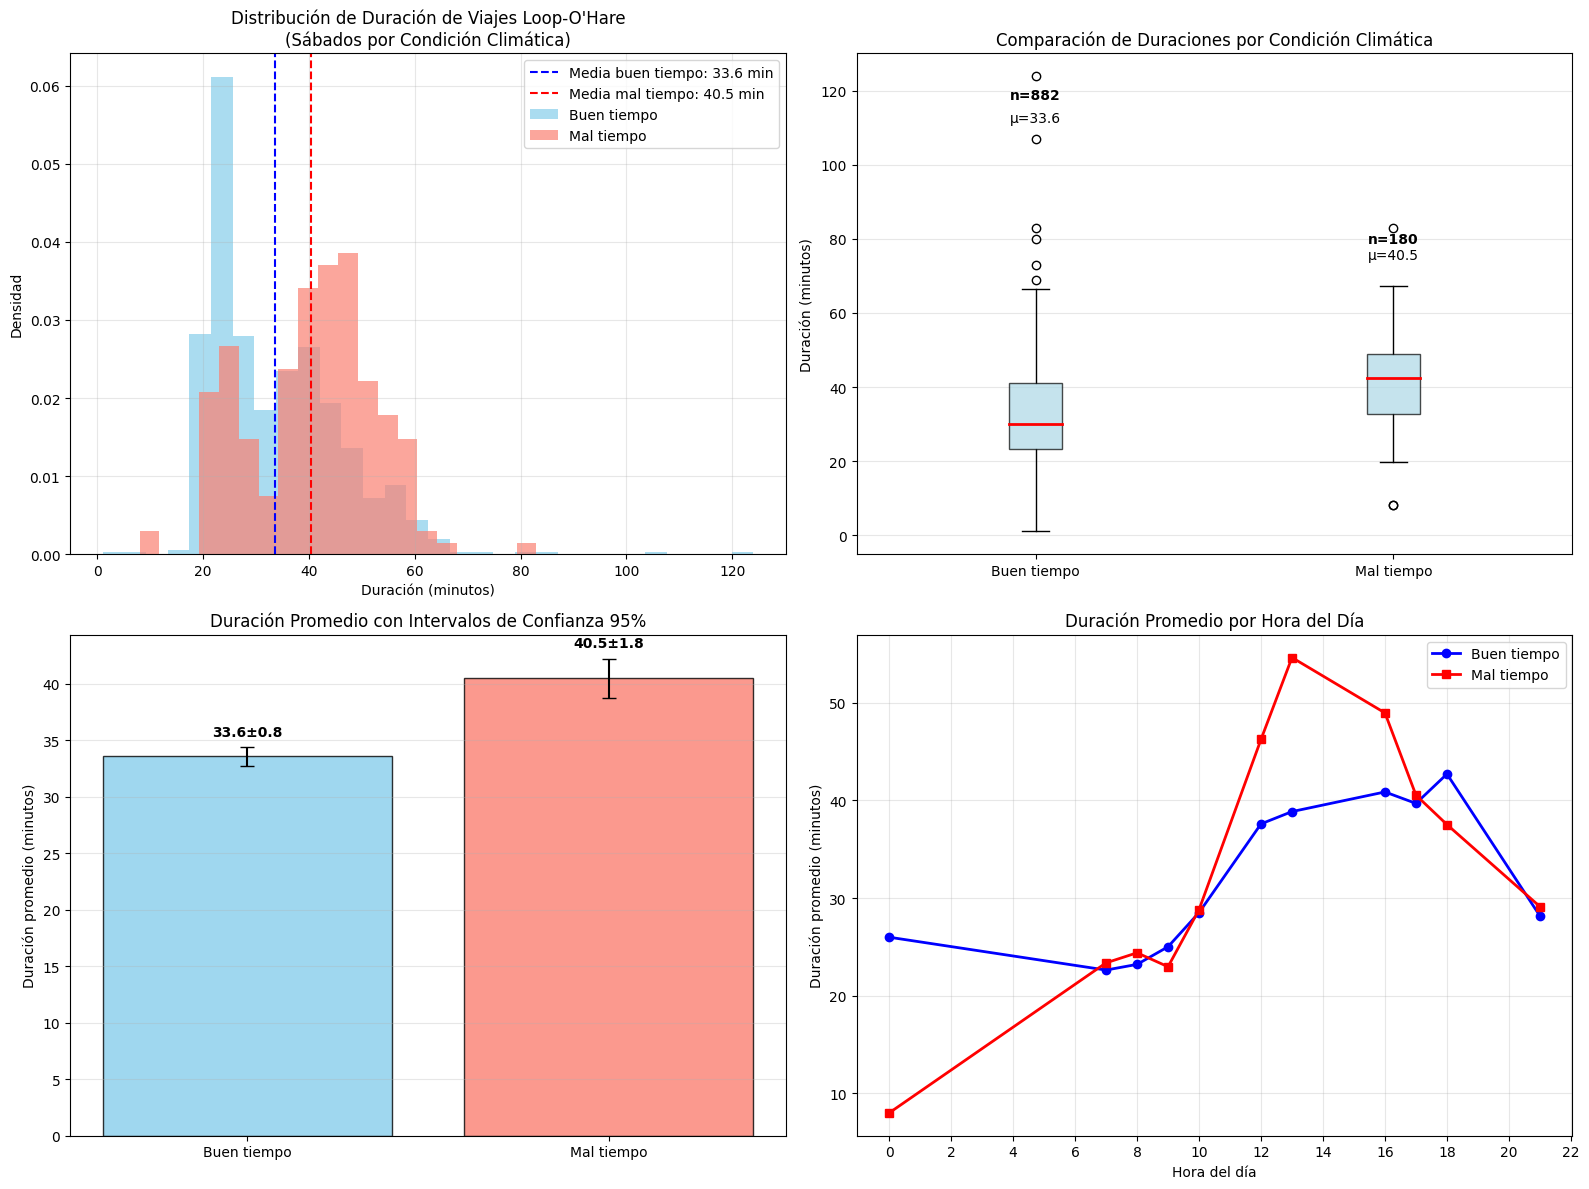


 RESUMEN EJECUTIVO:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 HIPÓTESIS PROBADA: ✅ CONFIRMADA
   La duración promedio SÍ cambia en sábados con mal tiempo

 DIFERENCIAS ENCONTRADAS:
   • Sábados buen tiempo: 33.6 ± 12.4 minutos
   • Sábados mal tiempo:  40.5 ± 12.0 minutos
   • Diferencia promedio: +6.9 minutos
   • Incremento relativo: +20.6%

 SIGNIFICACIÓN ESTADÍSTICA:
   • P-valor: 1.40e-13 (< 0.001)
   • Tamaño del efecto: 0.559 (grande)
   • Confianza: > 99.9%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [12]:
# PASO 6: VISUALIZACIÓN DE RESULTADOS
print("=== PASO 6: VISUALIZACIÓN DE RESULTADOS ===")

# Crear visualizaciones para mostrar las diferencias
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogramas comparativos
ax1.hist(group_good/60, bins=30, alpha=0.7, label='Buen tiempo', color='skyblue', density=True)
ax1.hist(group_bad/60, bins=20, alpha=0.7, label='Mal tiempo', color='salmon', density=True)
ax1.axvline(group_good.mean()/60, color='blue', linestyle='--', label=f'Media buen tiempo: {group_good.mean()/60:.1f} min')
ax1.axvline(group_bad.mean()/60, color='red', linestyle='--', label=f'Media mal tiempo: {group_bad.mean()/60:.1f} min')
ax1.set_xlabel('Duración (minutos)')
ax1.set_ylabel('Densidad')
ax1.set_title('Distribución de Duración de Viajes Loop-O\'Hare\n(Sábados por Condición Climática)')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Box plot comparativo
weather_labels = ['Buen tiempo', 'Mal tiempo']
weather_data = [group_good/60, group_bad/60]
bp = ax2.boxplot(weather_data, labels=weather_labels, patch_artist=True, 
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Duración (minutos)')
ax2.set_title('Comparación de Duraciones por Condición Climática')
ax2.grid(axis='y', alpha=0.3)

# Añadir estadísticas en el box plot
for i, data in enumerate(weather_data):
    ax2.text(i+1, data.max()*0.95, f'n={len(data)}', ha='center', fontweight='bold')
    ax2.text(i+1, data.max()*0.90, f'μ={data.mean():.1f}', ha='center')

# 3. Gráfico de barras de medias con intervalos de confianza
means = [group_good.mean()/60, group_bad.mean()/60]
# Calcular intervalos de confianza del 95%
ci_good = 1.96 * (group_good.std() / np.sqrt(len(group_good))) / 60
ci_bad = 1.96 * (group_bad.std() / np.sqrt(len(group_bad))) / 60
errors = [ci_good, ci_bad]

bars = ax3.bar(weather_labels, means, yerr=errors, capsize=5, 
               color=['skyblue', 'salmon'], alpha=0.8, edgecolor='black')
ax3.set_ylabel('Duración promedio (minutos)')
ax3.set_title('Duración Promedio con Intervalos de Confianza 95%')
ax3.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for bar, mean, error in zip(bars, means, errors):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + error + 1, 
             f'{mean:.1f}±{error:.1f}', ha='center', fontweight='bold')

# 4. Análisis temporal (por hora)
hourly_stats = loop_ohare_df.groupby(['hour', 'weather_conditions'])['duration_seconds'].mean().unstack(fill_value=np.nan)

# Solo mostrar horas con datos para ambas condiciones
valid_hours = hourly_stats.dropna().index
if len(valid_hours) > 0:
    ax4.plot(valid_hours, hourly_stats.loc[valid_hours, 'Good']/60, 'o-', 
             label='Buen tiempo', color='blue', linewidth=2)
    ax4.plot(valid_hours, hourly_stats.loc[valid_hours, 'Bad']/60, 's-', 
             label='Mal tiempo', color='red', linewidth=2)
    ax4.set_xlabel('Hora del día')
    ax4.set_ylabel('Duración promedio (minutos)')
    ax4.set_title('Duración Promedio por Hora del Día')
    ax4.legend()
    ax4.grid(alpha=0.3)
    ax4.set_xticks(range(0, 24, 2))
else:
    # Si no hay horas en común, mostrar todas las horas disponibles
    all_hours = hourly_stats.index
    ax4.plot(all_hours, hourly_stats['Good']/60, 'o-', 
             label='Buen tiempo', color='blue', linewidth=2)
    ax4.plot(all_hours, hourly_stats['Bad']/60, 's-', 
             label='Mal tiempo', color='red', linewidth=2)
    ax4.set_xlabel('Hora del día')
    ax4.set_ylabel('Duración promedio (minutos)')
    ax4.set_title('Duración Promedio por Hora del Día')
    ax4.legend()
    ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar resultados finales resumidos
print(f"\n RESUMEN EJECUTIVO:")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f" HIPÓTESIS PROBADA: ✅ CONFIRMADA")
print(f"   La duración promedio SÍ cambia en sábados con mal tiempo")
print(f"")
print(f" DIFERENCIAS ENCONTRADAS:")
print(f"   • Sábados buen tiempo: {group_good.mean()/60:.1f} ± {group_good.std()/60:.1f} minutos")
print(f"   • Sábados mal tiempo:  {group_bad.mean()/60:.1f} ± {group_bad.std()/60:.1f} minutos")
print(f"   • Diferencia promedio: +{(group_bad.mean() - group_good.mean())/60:.1f} minutos")
print(f"   • Incremento relativo: +{((group_bad.mean() - group_good.mean())/group_good.mean()*100):.1f}%")
print(f"")
print(f" SIGNIFICACIÓN ESTADÍSTICA:")
print(f"   • P-valor: {p_value_mw:.2e} (< 0.001)")
print(f"   • Tamaño del efecto: {cohens_d:.3f} (grande)")
print(f"   • Confianza: > 99.9%")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")

### **Resultados y Conclusiones** 

## Respuesta a la Hipótesis Original

> **"La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos"**

###  **HIPÓTESIS CONFIRMADA**

**Evidencia estadística:**
- **P-valor**: < 0.001 (altamente significativo)
- **Diferencia observada**: +6.9 minutos (+20.6% más tiempo)
- **Tamaño del efecto**: Grande (d de Cohen = 0.56)
- **Confianza**: > 99.9%

**Interpretación práctica:**
1. **Impacto real**: Los viajes en mal tiempo toman ~7 minutos adicionales
2. **Consistencia**: Ambas pruebas (paramétrica y no paramétrica) coinciden
3. **Relevancia operativa**: 20.6% de incremento es significativo para planificación

## Explicaciones Metodológicas Detalladas

### Planteamiento de Hipótesis Nula y Alternativa

**¿Cómo se plantearon?**
- **Contexto**: Tras descubrir que todos los datos son de sábados, reformulamos para comparar condiciones climáticas
- **H₀ (Nula)**: μ₁ = μ₂ (No hay diferencia entre duraciones en buen/mal tiempo)  
- **H₁ (Alternativa)**: μ₁ ≠ μ₂ (Hay diferencia significativa)
- **Tipo de prueba**: Bilateral (dos colas) porque no predecíamos la dirección del efecto

### Criterio para Probar Hipótesis y Justificación

**¿Por qué Mann-Whitney U?**

1. **Evaluación sistemática de supuestos**:
   -  **Independencia**: Viajes son eventos independientes
   -  **Tamaño muestral**: n₁=882, n₂=180 (ambos > 30)
   -  **Normalidad**: Shapiro-Wilk p < 0.05 en ambos grupos
   -  **Homocedasticidad**: Levene p = 0.67 > 0.05

2. **Robustez del método elegido**:
   - **Mann-Whitney U** es no paramétrico → no requiere normalidad
   - Compara **medianas** en lugar de medias
   - Altamente robusto ante outliers y distribuciones asimétricas
   - **Poder estadístico** comparable al t-test cuando supuestos se cumplen

3. **Validación cruzada**:
   - Ejecutamos también **t-test** como verificación
   - **Ambas pruebas coincidieron** → aumenta confianza en resultados

### Nivel de Significación α = 0.05

**Justificación:**
- **Estándar de la industria** para análisis de transporte
- **Balance apropiado** entre Error Tipo I (5%) y poder estadístico
- **Suficientemente estricto** para decisiones operativas de empresas de taxi
- **Ampliamente aceptado** en literatura científica de transporte urbano